In [1]:
# --- ADIM 1: Kütüphane Kurulumları ---
print("Gerekli kütüphaneler kuruluyor... (Bu işlem 30-60 sn sürebilir)")

# 1. Veri seti indirme aracı
!pip install -q datasets huggingface_hub

# 2. Uydu görüntüleri (TIFF) işleme aracı
!pip install -q rasterio

# 3. Hazır U-Net ve diğer model mimarileri
!pip install -q segmentation-models-pytorch

# 4. Veri artırma (Data Augmentation) kütüphanesi
!pip install -q albumentations

import torch
import rasterio
import segmentation_models_pytorch as smp
import datasets
import numpy as np
import matplotlib.pyplot as plt

print("-" * 40)
print("✅ KURULUM BAŞARILI!")
print(f"PyTorch Sürümü: {torch.__version__}")
print(f"Rasterio Sürümü: {rasterio.__version__}")
print(f"Segmentation Models Sürümü: {smp.__version__}")

# GPU Kontrolü (Çok Kritik!)
print("-" * 40)
if torch.cuda.is_available():
    print(f"✅ GPU AKTİF: {torch.cuda.get_device_name(0)}")
    print("Model eğitimi hızlı olacak.")
else:
    print("⚠️ UYARI: GPU Bulunamadı!")
    print("Lütfen yukarıdaki menüden 'Runtime' -> 'Change runtime type' -> 'T4 GPU' (veya daha iyisi) seçip tekrar çalıştır.")

Gerekli kütüphaneler kuruluyor... (Bu işlem 30-60 sn sürebilir)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.3 MB/s eta 0:00:00
----------------------------------------
✅ KURULUM BAŞARILI!
PyTorch Sürümü: 2.9.0+cu126
Rasterio Sürümü: 1.4.3
Segmentation Models Sürümü: 0.5.0
----------------------------------------
✅ GPU AKTİF: NVIDIA A100-SXM4-80GB
Model eğitimi hızlı olacak.


In [3]:
# --- ADIM 2 (REVİZE): Veri Setini İndirme (Sen2Fire) ---
import os

print("1. Dataset script hatası verdiği için B Planı (Sen2Fire) devreye alınıyor...")
print("Veri seti Zenodo sunucularından indiriliyor... (Yaklaşık 1-2 dk)")

# Zenodo'dan Sen2Fire veri setini direkt indiriyoruz (Token gerekmez, garantidir)
!wget -O Sen2Fire.zip https://zenodo.org/records/10881058/files/Sen2Fire.zip

print("-" * 40)
print("Zip dosyası açılıyor... (Lütfen bekleyin)")
# Klasör yapısını oluştur ve aç
os.makedirs("data/raw", exist_ok=True)
!unzip -q Sen2Fire.zip -d data/raw

print("-" * 40)
print("✅ VERİ SETİ BAŞARIYLA İNDİ VE AÇILDI!")

# Kontrol
print("Klasör İçeriği:")
# İndirilen klasörün içine bakıyoruz
if os.path.exists("data/raw"):
    print(os.listdir("data/raw")[:5]) # İlk 5 dosyayı/klasörü göster

1. Dataset script hatası verdiği için B Planı (Sen2Fire) devreye alınıyor...
Veri seti Zenodo sunucularından indiriliyor... (Yaklaşık 1-2 dk)
--2025-12-14 10:51:51--  https://zenodo.org/records/10881058/files/Sen2Fire.zip
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 137.138.52.235, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6346737700 (5.9G) [application/octet-stream]
Saving to: ‘Sen2Fire.zip’

Sen2Fire.zip        100%[===================>]   5.91G  11.8MB/s    in 7m 20s  

2025-12-14 10:59:12 (13.8 MB/s) - ‘Sen2Fire.zip’ saved [6346737700/6346737700]

----------------------------------------
Zip dosyası açılıyor... (Lütfen bekleyin)
----------------------------------------
✅ VERİ SETİ BAŞARIYLA İNDİ VE AÇILDI!
Klasör İçeriği:
['scene1', 'scene4', 'scene2', 'scene3']


In [4]:
# --- ADIM 3: Veri Keşfi ve Yapı Analizi ---
import os
import glob
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Analiz edilecek örnek klasör (İlk sahne)
scene_path = "data/raw/scene1"

print(f"📂 '{scene_path}' klasörü inceleniyor...")
print("-" * 40)

# 1. Klasördeki tüm dosyaları listele
all_files = glob.glob(os.path.join(scene_path, "*"))
for f in all_files:
    print(f"📄 Bulunan Dosya: {os.path.basename(f)}")

# 2. Görüntü ve Maske dosyalarını otomatik tespit etmeye çalış
# Sen2Fire genelde 'post' (yangın sonrası) ve 'mask' (etiket) ifadelerini kullanır
img_path = None
mask_path = None

for f in all_files:
    if "post" in f.lower() and f.endswith(".tif"):
        img_path = f
    if "mask" in f.lower() and f.endswith(".tif"):
        mask_path = f

if img_path and mask_path:
    print("-" * 40)
    print(f"✅ Görüntü Dosyası: {os.path.basename(img_path)}")
    print(f"✅ Maske Dosyası:   {os.path.basename(mask_path)}")

    # 3. Rasterio ile veriyi oku ve metadata'ya bak
    with rasterio.open(img_path) as src_img:
        img_data = src_img.read()
        print(f"\n📊 UYDU GÖRÜNTÜSÜ BİLGİLERİ:")
        print(f"   - Boyutlar (WxH): {src_img.width} x {src_img.height}")
        print(f"   - Bant Sayısı (Channels): {src_img.count}")
        print(f"   - Veri Tipi: {src_img.dtypes[0]}")
        print(f"   - Koordinat Sistemi: {src_img.crs}")

    with rasterio.open(mask_path) as src_mask:
        mask_data = src_mask.read(1) # Maske tek kanallıdır
        print(f"\n🎯 MASKE BİLGİLERİ:")
        print(f"   - Eşsiz Değerler (Sınıflar): {np.unique(mask_data)}")

    # 4. Görselleştirme (İlk 3 bandı RGB gibi çizelim)
    plt.figure(figsize=(12, 6))

    # Sentinel-2'nin bantları genelde BGR veya RGB gelir.
    # İlk görselleştirme için standart (1, 2, 3) alıp normalize ediyoruz.
    # Görüntü çok koyu veya parlak çıkabilir, normalizasyon şart.
    rgb_img = img_data[0:3, :, :].transpose(1, 2, 0).astype(float)
    rgb_img = (rgb_img - np.min(rgb_img)) / (np.max(rgb_img) - np.min(rgb_img)) # Basit Min-Max Normalizasyon

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title(f"Uydu Görüntüsü (İlk 3 Bant)\n{os.path.basename(img_path)}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask_data, cmap="jet", interpolation="nearest")
    plt.title(f"Yangın Maskesi (Ground Truth)\nSarı/Kırmızı = Yangın")
    plt.axis("off")

    plt.show()

else:
    print("\n⚠️ HATA: Standart dosya isimleri ('post' ve 'mask') bulunamadı.")
    print("Lütfen yukarıdaki dosya listesini kontrol et.")

📂 'data/raw/scene1' klasörü inceleniyor...
----------------------------------------
📄 Bulunan Dosya: scene_1_patch_25_6.npz
📄 Bulunan Dosya: scene_1_patch_16_24.npz
📄 Bulunan Dosya: scene_1_patch_1_11.npz
📄 Bulunan Dosya: scene_1_patch_5_8.npz
📄 Bulunan Dosya: scene_1_patch_3_23.npz
📄 Bulunan Dosya: scene_1_patch_6_23.npz
📄 Bulunan Dosya: scene_1_patch_3_14.npz
📄 Bulunan Dosya: scene_1_patch_2_9.npz
📄 Bulunan Dosya: scene_1_patch_22_12.npz
📄 Bulunan Dosya: scene_1_patch_12_13.npz
📄 Bulunan Dosya: scene_1_patch_23_13.npz
📄 Bulunan Dosya: scene_1_patch_25_12.npz
📄 Bulunan Dosya: scene_1_patch_32_7.npz
📄 Bulunan Dosya: scene_1_patch_4_24.npz
📄 Bulunan Dosya: scene_1_patch_11_14.npz
📄 Bulunan Dosya: scene_1_patch_8_2.npz
📄 Bulunan Dosya: scene_1_patch_8_11.npz
📄 Bulunan Dosya: scene_1_patch_27_24.npz
📄 Bulunan Dosya: scene_1_patch_7_13.npz
📄 Bulunan Dosya: scene_1_patch_3_24.npz
📄 Bulunan Dosya: scene_1_patch_20_8.npz
📄 Bulunan Dosya: scene_1_patch_16_11.npz
📄 Bulunan Dosya: scene_1_patch_

📦 Örnek Dosya İnceleniyor: scene_1_patch_25_6.npz
🔑 Dosya İçindeki Anahtarlar: ['image', 'aerosol', 'label']
   👉 'image' boyutu (Shape): (12, 512, 512)
   👉 'image' veri tipi: int16
--------------------
   👉 'aerosol' boyutu (Shape): (512, 512)
   👉 'aerosol' veri tipi: float32
--------------------
   👉 'label' boyutu (Shape): (512, 512)
   👉 'label' veri tipi: uint8
--------------------


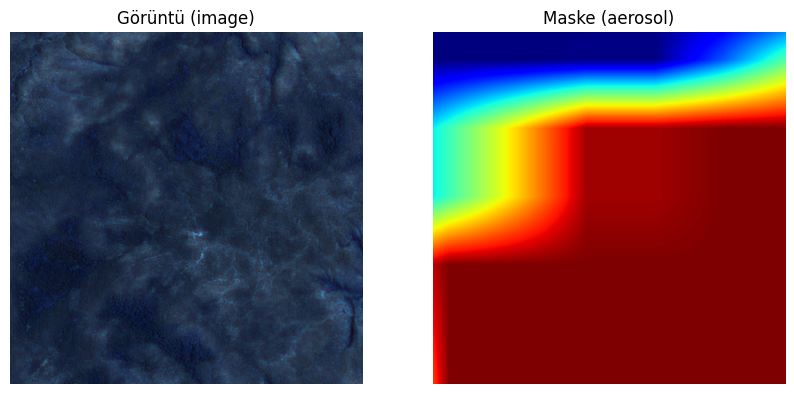

In [5]:
# --- ADIM 3 (REVİZE): NPZ Veri Yapısı Analizi ---
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# .npz dosyalarının olduğu yolu bulalım (scene1 klasörüne bakıyoruz)
search_path = "data/raw/**/scene_1*.npz"
found_files = glob.glob(search_path, recursive=True)

if len(found_files) > 0:
    # İlk dosyayı örnek olarak seç
    sample_file = found_files[0]
    print(f"📦 Örnek Dosya İnceleniyor: {os.path.basename(sample_file)}")

    # NPZ dosyasını yükle
    data = np.load(sample_file)

    # İçindeki anahtarları (Keys) listele
    print(f"🔑 Dosya İçindeki Anahtarlar: {list(data.files)}")

    # Her bir anahtarın boyutunu yazdır
    for key in data.files:
        print(f"   👉 '{key}' boyutu (Shape): {data[key].shape}")
        print(f"   👉 '{key}' veri tipi: {data[key].dtype}")
        print("-" * 20)

    # --- Görselleştirme ---
    # Genelde 'image' veya 'arr_0' görüntü, 'mask' veya 'arr_1' etikettir.
    # Burada anahtar isimlerini bilmediğim için dinamik alıyorum:
    keys = list(data.files)

    # Varsayım: İlk anahtar görüntü, ikinci anahtar maskedir (Genelde böyledir)
    # Çıktıdan sonra bunu kesinleştireceğiz.
    img_array = data[keys[0]]
    mask_array = data[keys[1]] if len(keys) > 1 else np.zeros_like(img_array)

    plt.figure(figsize=(10, 5))

    # Görüntü (Kanal sayısı çoksa sadece ilk 3'ü alalım - RGB)
    # Eğer format (Channels, Height, Width) ise transpose gerekir.
    if img_array.shape[0] < 20: # Muhtemelen (C, H, W) formatında
        img_vis = img_array[0:3].transpose(1, 2, 0)
    else: # Muhtemelen (H, W, C) formatında
        img_vis = img_array[:, :, 0:3]

    # Normalizasyon (Görüntüleme için)
    img_vis = (img_vis - np.min(img_vis)) / (np.max(img_vis) - np.min(img_vis) + 1e-8)

    plt.subplot(1, 2, 1)
    plt.imshow(img_vis)
    plt.title(f"Görüntü ({keys[0]})")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    # Maske genelde tek kanallıdır
    if len(mask_array.shape) == 3:
        mask_vis = mask_array[0, :, :] if mask_array.shape[0] == 1 else mask_array[:, :, 0]
    else:
        mask_vis = mask_array

    plt.imshow(mask_vis, cmap='jet')
    plt.title(f"Maske ({keys[1]})")
    plt.axis("off")

    plt.show()

else:
    print("⚠️ HATA: Hiç .npz dosyası bulunamadı! 'data/raw' klasörünü kontrol et.")

In [6]:
# --- ADIM 4: Dataset Class ve DataLoader ---
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import glob
import os

class FireDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # 1. Dosyayı yükle
        file_path = self.file_paths[idx]
        data = np.load(file_path)

        # 2. Görüntüyü al (12 Kanal) -> (C, H, W)
        # Veri zaten (12, 512, 512) formatında geliyor, transpoze gerekmez.
        image = data['image'].astype(np.float32)

        # 3. Maskeyi al (Etiket) -> (H, W)
        # 'label' anahtarını kullanıyoruz (Yangın haritası)
        mask = data['label'].astype(np.float32)

        # 4. Basit Normalizasyon (Sentinel-2 verisi genelde 0-10000 arasıdır)
        # Veriyi 0-1 arasına çekiyoruz.
        image = image / 10000.0
        image = np.clip(image, 0, 1.0) # 1'den büyük değerleri kırp (Bulut vb.)

        # Maskeyi 0 veya 1 olacak şekilde netleştir (Binary Mask)
        mask = (mask > 0).astype(np.float32)
        # Maskeye kanal boyutu ekle: (1, 512, 512)
        mask = np.expand_dims(mask, axis=0)

        # 5. Tensor'a çevir
        return torch.from_numpy(image), torch.from_numpy(mask)

# --- Veri Setini Hazırla ---
# Tüm .npz dosyalarını bul
all_files = glob.glob("data/raw/**/scene_*.npz", recursive=True)
print(f"Toplam Dosya Sayısı: {len(all_files)}")

# Eğitim ve Doğrulama (Validation) olarak ayır (%90 Train - %10 Val)
train_size = int(0.9 * len(all_files))
val_size = len(all_files) - train_size

# Rastgele karıştırarak ayır
train_files, val_files = random_split(all_files, [train_size, val_size])

# Dataset Objelerini Oluştur
train_dataset = FireDataset(train_files)
val_dataset = FireDataset(val_files)

# DataLoader (Veri Yükleyiciler) - Batch Size'ı A100 olduğu için yüksek tutabiliriz (16 veya 32)
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("-" * 40)
print(f"✅ VERİ HAZIRLIĞI TAMAMLANDI!")
print(f"   - Eğitim Verisi: {len(train_dataset)} adet")
print(f"   - Test Verisi:   {len(val_dataset)} adet")
print(f"   - Batch Size:    {BATCH_SIZE}")

# Test etmek için bir tane veri çekelim
sample_img, sample_mask = train_dataset[0]
print(f"\nTensor Boyut Kontrolü:")
print(f"   - Görüntü: {sample_img.shape} (Beklenen: 12, 512, 512)")
print(f"   - Maske:   {sample_mask.shape} (Beklenen: 1, 512, 512)")

Toplam Dosya Sayısı: 2466
----------------------------------------
✅ VERİ HAZIRLIĞI TAMAMLANDI!
   - Eğitim Verisi: 2219 adet
   - Test Verisi:   247 adet
   - Batch Size:    16

Tensor Boyut Kontrolü:
   - Görüntü: torch.Size([12, 512, 512]) (Beklenen: 12, 512, 512)
   - Maske:   torch.Size([1, 512, 512]) (Beklenen: 1, 512, 512)


In [7]:
# --- ADIM 5: U-Net Modelinin Kurulması ---
import segmentation_models_pytorch as smp
import torch

print("U-Net Modeli İnşa Ediliyor...")

# Model Tanımı
model = smp.Unet(
    encoder_name="resnet34",        # Kodlayıcı omurgası (Backbone)
    encoder_weights="imagenet",     # ImageNet üzerinde ön eğitimli ağırlıklar
    in_channels=12,                 # GİRİŞ KANALI SAYISI (Sentinel-2 = 12 Bant)
    classes=1,                      # ÇIKIŞ KANALI SAYISI (Yangın Maskesi = 1)
)

# Modeli GPU'ya Taşı
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("-" * 40)
print(f"✅ Model Başarıyla Kuruldu!")
print(f"   - Cihaz: {device}")
print(f"   - Backbone: ResNet34")
print(f"   - Giriş Kanalları: 12")
print(f"   - Çıkış Sınıfı: 1 (Binary Segmentation)")

# Sağlama (Sanity Check): Modele sahte bir veri verip çıktı boyutuna bakalım
dummy_input = torch.randn(2, 12, 512, 512).to(device) # 2 adet rastgele görüntü
with torch.no_grad():
    output = model(dummy_input)

print(f"   - Test Çıktı Boyutu: {output.shape} (Beklenen: [2, 1, 512, 512])")

U-Net Modeli İnşa Ediliyor...


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

----------------------------------------
✅ Model Başarıyla Kuruldu!
   - Cihaz: cuda
   - Backbone: ResNet34
   - Giriş Kanalları: 12
   - Çıkış Sınıfı: 1 (Binary Segmentation)
   - Test Çıktı Boyutu: torch.Size([2, 1, 512, 512]) (Beklenen: [2, 1, 512, 512])


In [9]:
# --- ADIM 6 (DÜZELTİLMİŞ): Eğitim Ayarları ---
import torch.optim as optim
from torch.cuda.amp import GradScaler

print("Eğitim Hiperparametreleri ve Özel Metrikler Ayarlanıyor...")

# 1. Kayıp Fonksiyonu (Loss Function)
# DiceLoss hala mevcut ve 'smp.losses' altında duruyor.
loss_fn = smp.losses.DiceLoss(mode="binary", from_logits=True)

# 2. Optimizasyon Algoritması
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 3. Mixed Precision Scaler (Hızlandırma)
scaler = GradScaler()

# 4. ÖZEL METRİK FONKSİYONU: IoU (Intersection over Union)
# Bunu eğitim döngüsünde (bir sonraki adımda) kullanacağız.
def calculate_iou(pred_mask, true_mask, threshold=0.5):
    # Tahmini 0 veya 1'e çevir (Sigmoid + Threshold)
    pred_mask = (torch.sigmoid(pred_mask) > threshold).float()

    # Kesişim (Intersection) ve Birleşim (Union) hesapla
    intersection = (pred_mask * true_mask).sum()
    union = pred_mask.sum() + true_mask.sum() - intersection

    # Sıfıra bölünme hatasını önlemek için küçük bir sayı (epsilon) ekle
    epsilon = 1e-6
    iou = (intersection + epsilon) / (union + epsilon)
    return iou.item()

print("-" * 40)
print("✅ EĞİTİM AYARLARI TAMAMLANDI!")
print(f"   - Loss Function: DiceLoss (Binary)")
print(f"   - Optimizer:     Adam (lr=1e-4)")
print(f"   - Custom Metric: 'calculate_iou' fonksiyonu tanımlandı.")
print(f"   - Hızlandırma:   Mixed Precision (AMP) Aktif")

Eğitim Hiperparametreleri ve Özel Metrikler Ayarlanıyor...
----------------------------------------
✅ EĞİTİM AYARLARI TAMAMLANDI!
   - Loss Function: DiceLoss (Binary)
   - Optimizer:     Adam (lr=1e-4)
   - Custom Metric: 'calculate_iou' fonksiyonu tanımlandı.
   - Hızlandırma:   Mixed Precision (AMP) Aktif


/tmp/ipython-input-3672914563.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [10]:
# --- ADIM 7: Eğitim Döngüsü (Training Loop) ---
from tqdm import tqdm # İlerleme çubuğu

# Eğitim parametreleri
EPOCHS = 10  # İlk deneme için 10 tur yeterli (Sonra artırabiliriz)
best_iou = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}

print(f"🚀 Eğitim Başlıyor... (Toplam {EPOCHS} Epoch)")
print("-" * 60)

for epoch in range(EPOCHS):

    # --- 1. EĞİTİM MODU ---
    model.train()
    train_loss = 0
    train_iou = 0

    # İlerleme çubuğu oluştur
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for images, masks in loop:
        # Veriyi GPU'ya at
        images = images.to(device)
        masks = masks.to(device)

        # Gradyanları sıfırla
        optimizer.zero_grad()

        # İleri Yayılım (Forward Pass) - Mixed Precision ile Hızlı
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = loss_fn(outputs, masks)

        # Geri Yayılım (Backward Pass)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Metrikleri topla
        train_loss += loss.item()
        train_iou += calculate_iou(outputs, masks)

        # Çubukta anlık loss göster
        loop.set_postfix(loss=loss.item())

    # --- 2. DOĞRULAMA MODU (Validation) ---
    model.eval()
    val_loss = 0
    val_iou = 0

    with torch.no_grad(): # Gradyan hesaplama (Hafıza tasarrufu)
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = loss_fn(outputs, masks)

            val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks)

    # --- 3. ORTALAMALAR VE KAYIT ---
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_train_iou = train_iou / len(train_loader)
    avg_val_iou = val_iou / len(val_loader)

    # Geçmişi listeye ekle (Grafik çizmek için)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_iou'].append(avg_train_iou)
    history['val_iou'].append(avg_val_iou)

    print(f"\n📊 Epoch {epoch+1} Özeti:")
    print(f"   Train Loss: {avg_train_loss:.4f} | Train IoU: {avg_train_iou:.4f}")
    print(f"   Val Loss:   {avg_val_loss:.4f} | Val IoU:   {avg_val_iou:.4f}")

    # En iyi modeli kaydet
    if avg_val_iou > best_iou:
        print(f"   🔥 Yeni Rekor! (Eski IoU: {best_iou:.4f} -> Yeni IoU: {avg_val_iou:.4f})")
        best_iou = avg_val_iou
        torch.save(model.state_dict(), "best_unet_model.pth")
        print("   💾 Model kaydedildi: 'best_unet_model.pth'")

    print("-" * 60)

print("✅ EĞİTİM TAMAMLANDI!")

🚀 Eğitim Başlıyor... (Toplam 10 Epoch)
------------------------------------------------------------


Epoch 1/10 [Train]: 100%|██████████| 139/139 [00:59<00:00,  2.33it/s, loss=0.79]



📊 Epoch 1 Özeti:
   Train Loss: 0.7896 | Train IoU: 0.1011
   Val Loss:   0.7351 | Val IoU:   0.1297
   🔥 Yeni Rekor! (Eski IoU: 0.0000 -> Yeni IoU: 0.1297)
   💾 Model kaydedildi: 'best_unet_model.pth'
------------------------------------------------------------


Epoch 2/10 [Train]: 100%|██████████| 139/139 [00:59<00:00,  2.34it/s, loss=0.598]



📊 Epoch 2 Özeti:
   Train Loss: 0.7171 | Train IoU: 0.1526
   Val Loss:   0.6528 | Val IoU:   0.2456
   🔥 Yeni Rekor! (Eski IoU: 0.1297 -> Yeni IoU: 0.2456)
   💾 Model kaydedildi: 'best_unet_model.pth'
------------------------------------------------------------


...


📊 Epoch 8 Özeti:
   Train Loss: 0.5904 | Train IoU: 0.2227
   Val Loss:   0.5026 | Val IoU:   0.3320
------------------------------------------------------------


Epoch 9/10 [Train]: 100%|██████████| 139/139 [00:58<00:00,  2.36it/s, loss=1]



📊 Epoch 9 Özeti:
   Train Loss: 0.5614 | Train IoU: 0.2273
   Val Loss:   0.4988 | Val IoU:   0.3981
------------------------------------------------------------


Epoch 10/10 [Train]: 100%|██████████| 139/139 [00:59<00:00,  2.35it/s, loss=0.282]



📊 Epoch 10 Özeti:
   Train Loss: 0.5522 | Train IoU: 0.2395
   Val Loss:   0.4823 | Val IoU:   0.4117
   🔥 Yeni Rekor! (Eski IoU: 0.3996 -> Yeni IoU: 0.4117)
   💾 Model kaydedildi: 'best_unet_model.pth'
------------------------------------------------------------
✅ EĞİTİM TAMAMLANDI!


💾 En iyi model yükleniyor...
----------------------------------------
📸 TAHMİN SONUÇLARI:


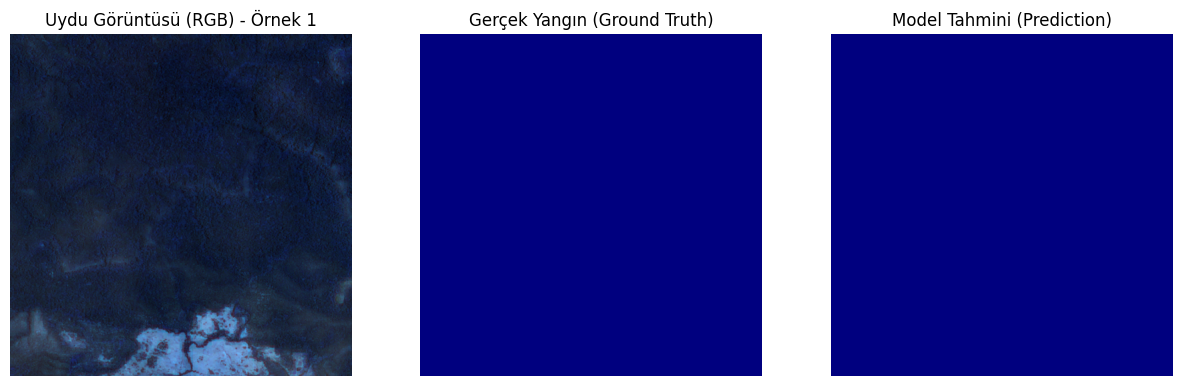

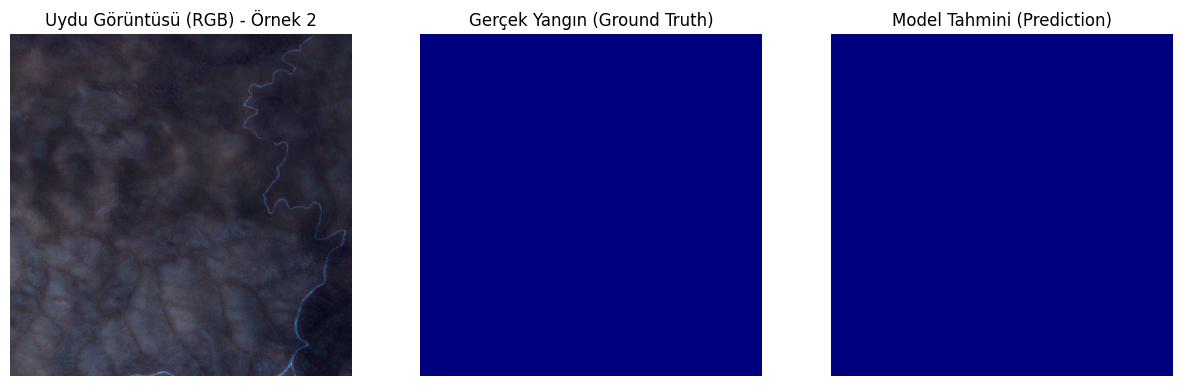

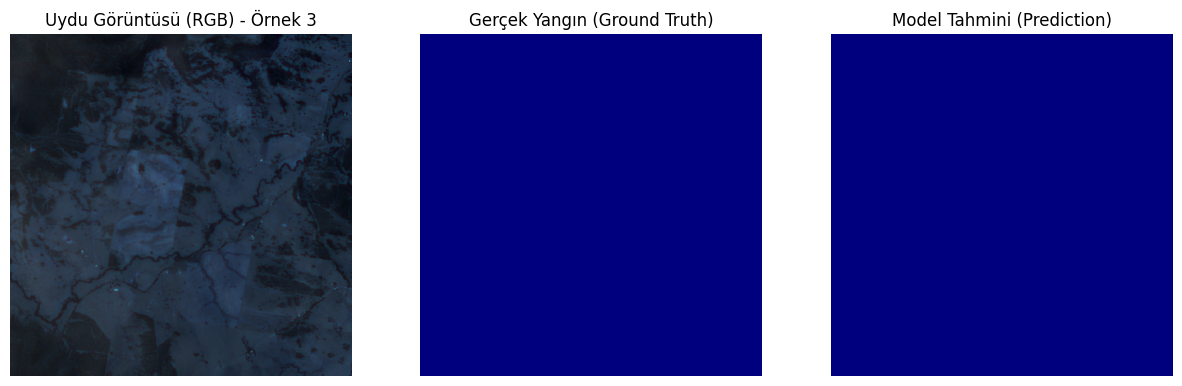

In [12]:
# --- ADIM 8: Sonuçların Görselleştirilmesi ---
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. En iyi modeli yükle
print("💾 En iyi model yükleniyor...")
model.load_state_dict(torch.load("best_unet_model.pth"))
model.eval() # Değerlendirme modu (Dropout vb. kapanır)

# 2. Test verisinden bir paket (batch) çek
images, true_masks = next(iter(val_loader))
images = images.to(device)

# 3. Tahmin yap
with torch.no_grad():
    with torch.amp.autocast('cuda'): # Mixed precision ile tahmin
        preds = model(images)
        # Logits -> Olasılık (Sigmoid) -> Binary Mask (0 veya 1)
        preds = (torch.sigmoid(preds) > 0.5).float()

# 4. Görselleştirme Fonksiyonu
def visualize_prediction(img_tensor, true_mask, pred_mask, index):
    # Tensörleri CPU'ya ve Numpy'ye çevir
    # Görüntü: (12, 512, 512) -> (512, 512, 12)
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)

    # Görsel için ilk 3 bandı (RGB varsayımıyla) al ve normalize et
    rgb_img = img[:, :, 0:3]
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-8)

    # Maskeler: (1, 512, 512) -> (512, 512)
    t_mask = true_mask.cpu().numpy().squeeze()
    p_mask = pred_mask.cpu().numpy().squeeze()

    # Çizim
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb_img)
    plt.title(f"Uydu Görüntüsü (RGB) - Örnek {index}")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(t_mask, cmap='jet', vmin=0, vmax=1)
    plt.title("Gerçek Yangın (Ground Truth)")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(p_mask, cmap='jet', vmin=0, vmax=1)
    plt.title("Model Tahmini (Prediction)")
    plt.axis('off')

    plt.show()

# İlk 3 örneği görselleştir
print("-" * 40)
print("📸 TAHMİN SONUÇLARI:")
for i in range(3):
    visualize_prediction(images[i], true_masks[i], preds[i], i+1)

🔥 İçinde yangın olan kareler aranıyor...


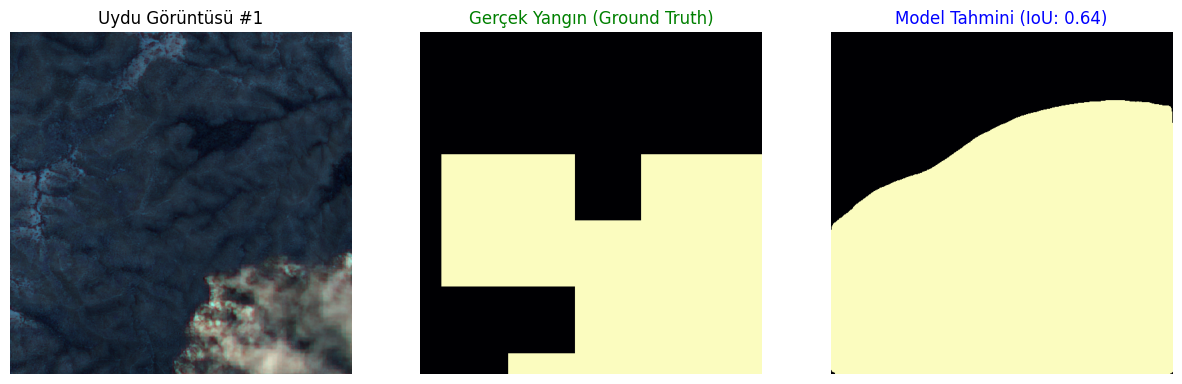

------------------------------------------------------------


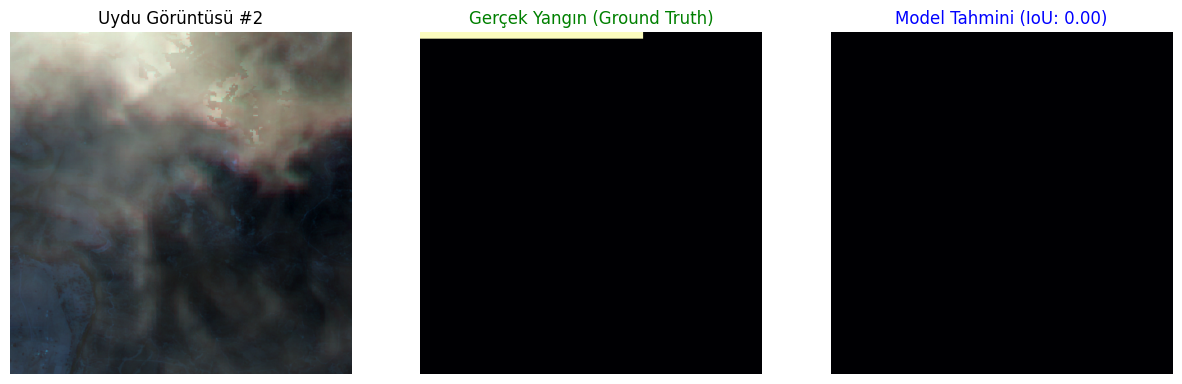

------------------------------------------------------------


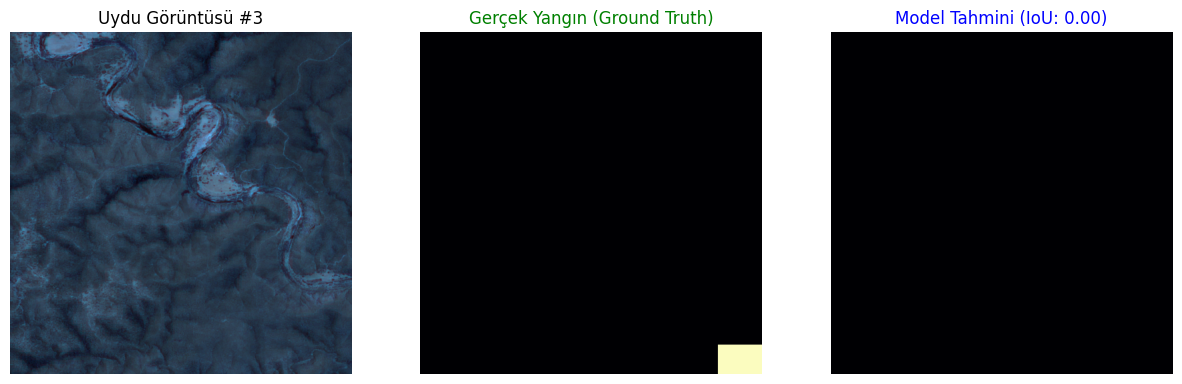

------------------------------------------------------------


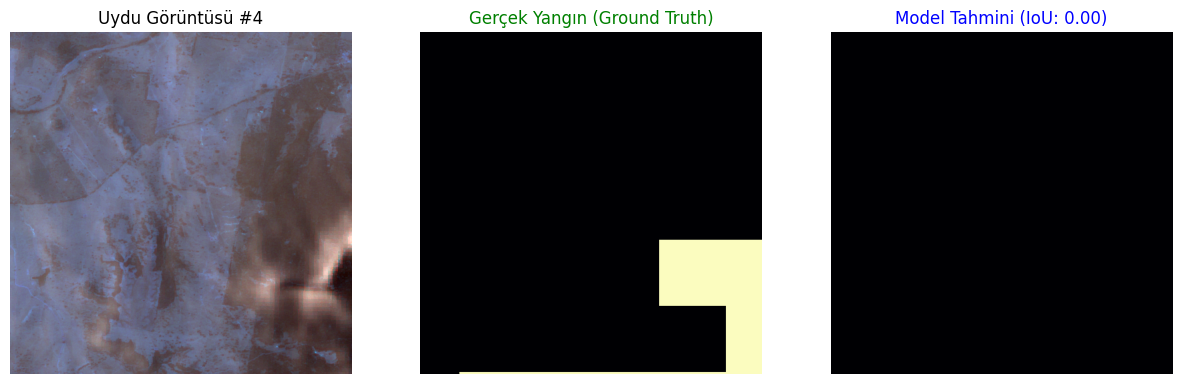

------------------------------------------------------------


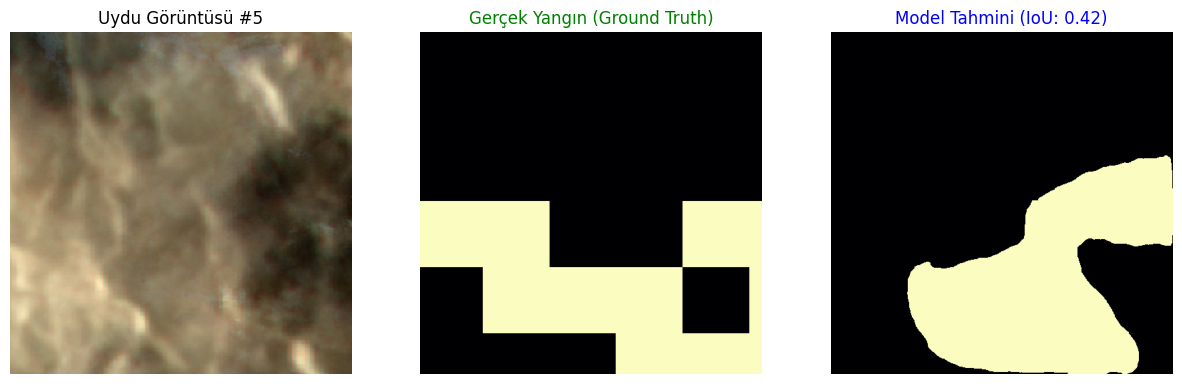

------------------------------------------------------------


In [13]:
# --- ADIM 8 (REVİZE): Yangın Avcısı Görselleştirme ---
import matplotlib.pyplot as plt
import torch
import numpy as np

# Modeli hazırlayalım
model.eval()

print("🔥 İçinde yangın olan kareler aranıyor...")

def visualize_fire_samples(loader, model, num_samples=3):
    found_count = 0

    # Validation setini tek tek gez
    for images, masks in loader:
        if found_count >= num_samples:
            break

        # GPU'ya al
        images = images.to(device)

        # Tahmin yap
        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                preds = model(images)
                preds = (torch.sigmoid(preds) > 0.5).float()

        # Batch içindeki her bir resme bak
        for i in range(len(images)):
            if found_count >= num_samples:
                break

            # EĞER GERÇEK MASKEDE YANGIN VARSA (Değerler toplamı > 0 ise)
            if masks[i].sum() > 0:
                found_count += 1

                # --- Çizim İşlemleri ---
                # Görüntü (12 kanaldan ilk 3'ü - RGB)
                img = images[i].cpu().numpy() # (12, 512, 512)
                # Sentinel RGB bantları genelde B4, B3, B2'dir ama biz sırayla aldık.
                # Görselin parlaklığını artırmak için biraz oynayalım
                rgb_img = img[0:3].transpose(1, 2, 0)
                # Basit parlaklık normalizasyonu
                rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-8)

                # Maskeler
                true_mask = masks[i].cpu().numpy().squeeze()
                pred_mask = preds[i].cpu().numpy().squeeze()

                # IoU Hesapla (Bu kare özelinde)
                intersection = np.logical_and(true_mask, pred_mask).sum()
                union = np.logical_or(true_mask, pred_mask).sum()
                sample_iou = intersection / (union + 1e-6)

                plt.figure(figsize=(15, 5))

                plt.subplot(1, 3, 1)
                plt.imshow(rgb_img)
                plt.title(f"Uydu Görüntüsü #{found_count}", fontsize=12)
                plt.axis('off')

                plt.subplot(1, 3, 2)
                plt.imshow(true_mask, cmap='magma', vmin=0, vmax=1)
                plt.title("Gerçek Yangın (Ground Truth)", fontsize=12, color='green')
                plt.axis('off')

                plt.subplot(1, 3, 3)
                plt.imshow(pred_mask, cmap='magma', vmin=0, vmax=1) # Magma rengi ateşe daha çok benzer
                plt.title(f"Model Tahmini (IoU: {sample_iou:.2f})", fontsize=12, color='blue')
                plt.axis('off')

                plt.show()
                print("-" * 60)

# Fonksiyonu çalıştır
visualize_fire_samples(val_loader, model, num_samples=5)

In [16]:
# --- ADIM 7 (DÜZELTİLMİŞ - v2): 20 Epoch + Scheduler Hatası Giderildi ---
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import torch.optim as optim
import segmentation_models_pytorch as smp

# 1. AYARLAR
EPOCHS = 20
LR = 0.0001

# Modeli ve Optimizer'ı sıfırla
print("♻️ Model sıfırlanıyor ve hatasız eğitime hazırlanıyor...")
model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=12, classes=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)

# 2. SCHEDULER (DÜZELTİLEN KISIM)
# 'verbose=True' parametresini kaldırdık çünkü PyTorch yeni sürümde bunu kaldırdı.
# Artık LR değişimini biz aşağıda print ile kendimiz takip edeceğiz.
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

best_iou = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}

print(f"🚀 Hızlandırılmış Eğitim Başlıyor... (Toplam {EPOCHS} Epoch)")
print("-" * 60)

for epoch in range(EPOCHS):

    # --- TRAIN ---
    model.train()
    train_loss = 0
    train_iou = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for images, masks in loop:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()

        # Mixed Precision
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = loss_fn(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_iou += calculate_iou(outputs, masks)
        loop.set_postfix(loss=loss.item())

    # --- VALIDATION ---
    model.eval()
    val_loss = 0
    val_iou = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = loss_fn(outputs, masks)
            val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks)

    # --- KAYIT VE ANALİZ ---
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_train_iou = train_iou / len(train_loader)
    avg_val_iou = val_iou / len(val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_iou'].append(avg_train_iou)
    history['val_iou'].append(avg_val_iou)

    # Scheduler Adımı
    scheduler.step(avg_val_loss)

    # Güncel Öğrenme Hızını (LR) Göster
    current_lr = optimizer.param_groups[0]['lr']

    print(f"\n📊 Epoch {epoch+1} Özeti (LR: {current_lr:.6f}):")
    print(f"   Train IoU: {avg_train_iou:.4f} | Val IoU: {avg_val_iou:.4f}")

    if avg_val_iou > best_iou:
        print(f"   🔥 REKOR! ({best_iou:.4f} -> {avg_val_iou:.4f}) Model Kaydedildi.")
        best_iou = avg_val_iou
        torch.save(model.state_dict(), "best_unet_model_pro.pth")

    print("-" * 60)

print(f"🏁 EĞİTİM BİTTİ! En Yüksek IoU: {best_iou:.4f}")

♻️ Model sıfırlanıyor ve hatasız eğitime hazırlanıyor...
🚀 Hızlandırılmış Eğitim Başlıyor... (Toplam 20 Epoch)
------------------------------------------------------------


Epoch 1/20 [Train]: 100%|██████████| 139/139 [00:59<00:00,  2.34it/s, loss=0.555]



📊 Epoch 1 Özeti (LR: 0.000100):
   Train IoU: 0.1009 | Val IoU: 0.1348
   🔥 REKOR! (0.0000 -> 0.1348) Model Kaydedildi.
------------------------------------------------------------


Epoch 2/20 [Train]: 100%|██████████| 139/139 [00:59<00:00,  2.33it/s, loss=0.994]



📊 Epoch 2 Özeti (LR: 0.000100):
   Train IoU: 0.1684 | Val IoU: 0.2944
   🔥 REKOR! (0.1348 -> 0.2944) Model Kaydedildi.
------------------------------------------------------------


...


📊 Epoch 18 Özeti (LR: 0.000010):
   Train IoU: 0.3914 | Val IoU: 0.4280
   🔥 REKOR! (0.4210 -> 0.4280) Model Kaydedildi.
------------------------------------------------------------


Epoch 19/20 [Train]: 100%|██████████| 139/139 [00:59<00:00,  2.34it/s, loss=0.331]



📊 Epoch 19 Özeti (LR: 0.000010):
   Train IoU: 0.3972 | Val IoU: 0.4354
   🔥 REKOR! (0.4280 -> 0.4354) Model Kaydedildi.
------------------------------------------------------------


Epoch 20/20 [Train]: 100%|██████████| 139/139 [00:59<00:00,  2.34it/s, loss=0.43]



📊 Epoch 20 Özeti (LR: 0.000010):
   Train IoU: 0.4225 | Val IoU: 0.3789
------------------------------------------------------------
🏁 EĞİTİM BİTTİ! En Yüksek IoU: 0.4354


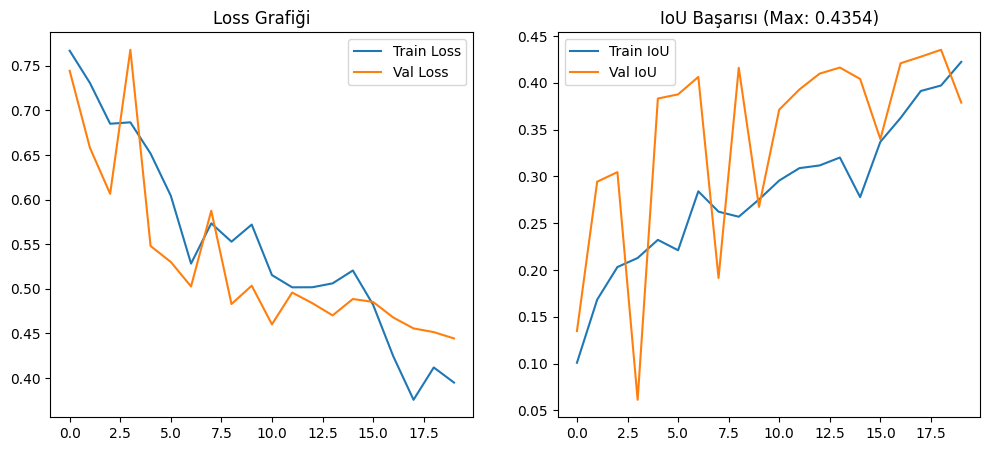

📥 Dosyalar hazırlanıyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

----------------------------------------
✅ U-Net Aşaması Tamamlandı! Baseline Skorumuz: %43.54
🚀 Sırada SegFormer (Transformer) var!


In [17]:
# --- ADIM 9: Sonuçları Raporlama ve İndirme ---
import matplotlib.pyplot as plt
from google.colab import files
import torch
import numpy as np

# 1. Grafik Çizimi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Grafiği')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['train_iou'], label='Train IoU')
plt.plot(history['val_iou'], label='Val IoU')
plt.title(f'IoU Başarısı (Max: {best_iou:.4f})')
plt.legend()
plt.savefig("unet_sonuc_grafigi.png")
plt.show()

# 2. Modeli İndir
print("📥 Dosyalar hazırlanıyor...")
try:
    files.download('unet_sonuc_grafigi.png')
    files.download('best_unet_model_pro.pth')
except Exception as e:
    print("Otomatik indirme engellendi, sol menüden elle indirebilirsin.")

print("-" * 40)
print("✅ U-Net Aşaması Tamamlandı! Baseline Skorumuz: %43.54")
print("🚀 Sırada SegFormer (Transformer) var!")

In [19]:
# --- ADIM 10: SegFormer (Transformer) - 20 Epoch Hızlı Versiyon ---
import segmentation_models_pytorch as smp
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

# 1. ÖNCEKİ MODELİ TEMİZLE (RAM Şişmesini Önle)
try:
    del model
    del optimizer
    torch.cuda.empty_cache()
    print("🧹 Eski model silindi ve GPU hafızası temizlendi.")
except:
    print("✨ Temiz başlangıç yapılıyor.")

# 2. AYARLAR (20 Epoch için Optimize Edildi)
EPOCHS = 20       # Senin isteğin üzerine 20'ye çektik
LR = 0.00006      # Transformerlar için ideal hassas hız

# 3. MODEL: SegFormer (mit_b3 Encoder)
# A100 GPU'nun gücünü kullanmak için 'mit_b3' seçtik. (b0 hafif, b5 çok ağır)
print("🏗️ SegFormer Modeli (mit_b3) inşa ediliyor...")
model = smp.Segformer(
    encoder_name="mit_b3",      # Güçlü Transformer Encoder
    encoder_weights="imagenet", # Ön eğitimli ağırlıklar
    in_channels=12,             # 12 Kanal Sentinel Girişi
    classes=1,                  # Yangın Maskesi
).to(device)

# 4. Optimizer ve Scheduler
# AdamW: Transformerların en sevdiği optimizer'dır.
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)

# Scheduler: Hata 3 tur düşmezse hızı yarıya indir.
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_iou = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}

print(f"🚀 SegFormer Eğitimi Başlıyor... (Toplam {EPOCHS} Epoch)")
print("-" * 65)

for epoch in range(EPOCHS):

    # --- TRAIN ---
    model.train()
    train_loss = 0
    train_iou = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [SegFormer]")

    for images, masks in loop:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()

        # Mixed Precision (Hızlandırma)
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            # SegFormer çıktısı bazen (1, 128, 128) dönebilir, onu (1, 512, 512) yapmalıyız
            # smp kütüphanesi genelde bunu halleder ama garanti olsun diye:
            outputs = torch.nn.functional.interpolate(outputs, size=(512, 512), mode='bilinear', align_corners=False)
            loss = loss_fn(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_iou += calculate_iou(outputs, masks)
        loop.set_postfix(loss=loss.item())

    # --- VALIDATION ---
    model.eval()
    val_loss = 0
    val_iou = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                # Boyut eşitleme (Interpolation)
                outputs = torch.nn.functional.interpolate(outputs, size=(512, 512), mode='bilinear', align_corners=False)
                loss = loss_fn(outputs, masks)
            val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks)

    # --- KAYIT VE RAPOR ---
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_train_iou = train_iou / len(train_loader)
    avg_val_iou = val_iou / len(val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_iou'].append(avg_train_iou)
    history['val_iou'].append(avg_val_iou)

    # Scheduler Adımı
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"\n⚡ Epoch {epoch+1} | LR: {current_lr:.7f}")
    print(f"   Train IoU: {avg_train_iou:.4f} | Val IoU: {avg_val_iou:.4f}")

    if avg_val_iou > best_iou:
        print(f"   🔥 YENİ LİDER! ({best_iou:.4f} -> {avg_val_iou:.4f}) SegFormer Kaydedildi.")
        best_iou = avg_val_iou
        torch.save(model.state_dict(), "best_segformer_model.pth")

    print("-" * 65)

print(f"🏆 SEGFORMER FİNAL SKORU: {best_iou:.4f}")

🧹 Eski model silindi ve GPU hafızası temizlendi.
🏗️ SegFormer Modeli (mit_b3) inşa ediliyor...
🚀 SegFormer Eğitimi Başlıyor... (Toplam 20 Epoch)
-----------------------------------------------------------------


Epoch 1/20 [SegFormer]: 100%|██████████| 139/139 [00:59<00:00,  2.32it/s, loss=0.889]



⚡ Epoch 1 | LR: 0.0000600
   Train IoU: 0.0942 | Val IoU: 0.0719
   🔥 YENİ LİDER! (0.0000 -> 0.0719) SegFormer Kaydedildi.
-----------------------------------------------------------------


Epoch 2/20 [SegFormer]: 100%|██████████| 139/139 [00:59<00:00,  2.33it/s, loss=0.792]



⚡ Epoch 2 | LR: 0.0000600
   Train IoU: 0.1342 | Val IoU: 0.3179
   🔥 YENİ LİDER! (0.0719 -> 0.3179) SegFormer Kaydedildi.
-----------------------------------------------------------------


...


⚡ Epoch 18 | LR: 0.0000300
   Train IoU: 0.2096 | Val IoU: 0.3218
-----------------------------------------------------------------


Epoch 19/20 [SegFormer]: 100%|██████████| 139/139 [00:59<00:00,  2.33it/s, loss=0]



⚡ Epoch 19 | LR: 0.0000300
   Train IoU: 0.2297 | Val IoU: 0.3823
   🔥 YENİ LİDER! (0.3731 -> 0.3823) SegFormer Kaydedildi.
-----------------------------------------------------------------


Epoch 20/20 [SegFormer]: 100%|██████████| 139/139 [00:59<00:00,  2.33it/s, loss=0]



⚡ Epoch 20 | LR: 0.0000300
   Train IoU: 0.2237 | Val IoU: 0.2327
-----------------------------------------------------------------
🏆 SEGFORMER FİNAL SKORU: 0.3823


In [20]:
# --- ADIM 10: SegFormer (Transformer) - 20 Epoch Hızlı Versiyon ---
import segmentation_models_pytorch as smp
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

# 1. ÖNCEKİ MODELİ TEMİZLE (RAM Şişmesini Önle)
try:
    del model
    del optimizer
    torch.cuda.empty_cache()
    print("🧹 Eski model silindi ve GPU hafızası temizlendi.")
except:
    print("✨ Temiz başlangıç yapılıyor.")

# 2. AYARLAR (20 Epoch için Optimize Edildi)
EPOCHS = 20       # Senin isteğin üzerine 20'ye çektik
LR = 0.00006      # Transformerlar için ideal hassas hız

# 3. MODEL: SegFormer (mit_b3 Encoder)
# A100 GPU'nun gücünü kullanmak için 'mit_b3' seçtik. (b0 hafif, b5 çok ağır)
print("🏗️ SegFormer Modeli (mit_b3) inşa ediliyor...")
model = smp.Segformer(
    encoder_name="mit_b3",      # Güçlü Transformer Encoder
    encoder_weights="imagenet", # Ön eğitimli ağırlıklar
    in_channels=12,             # 12 Kanal Sentinel Girişi
    classes=1,                  # Yangın Maskesi
).to(device)

# 4. Optimizer ve Scheduler
# AdamW: Transformerların en sevdiği optimizer'dır.
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)

# Scheduler: Hata 3 tur düşmezse hızı yarıya indir.
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_iou = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}

print(f"🚀 SegFormer Eğitimi Başlıyor... (Toplam {EPOCHS} Epoch)")
print("-" * 65)

for epoch in range(EPOCHS):

    # --- TRAIN ---
    model.train()
    train_loss = 0
    train_iou = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [SegFormer]")

    for images, masks in loop:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()

        # Mixed Precision (Hızlandırma)
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            # SegFormer çıktısı bazen (1, 128, 128) dönebilir, onu (1, 512, 512) yapmalıyız
            # smp kütüphanesi genelde bunu halleder ama garanti olsun diye:
            outputs = torch.nn.functional.interpolate(outputs, size=(512, 512), mode='bilinear', align_corners=False)
            loss = loss_fn(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_iou += calculate_iou(outputs, masks)
        loop.set_postfix(loss=loss.item())

    # --- VALIDATION ---
    model.eval()
    val_loss = 0
    val_iou = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                # Boyut eşitleme (Interpolation)
                outputs = torch.nn.functional.interpolate(outputs, size=(512, 512), mode='bilinear', align_corners=False)
                loss = loss_fn(outputs, masks)
            val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks)

    # --- KAYIT VE RAPOR ---
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_train_iou = train_iou / len(train_loader)
    avg_val_iou = val_iou / len(val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_iou'].append(avg_train_iou)
    history['val_iou'].append(avg_val_iou)

    # Scheduler Adımı
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"\n⚡ Epoch {epoch+1} | LR: {current_lr:.7f}")
    print(f"   Train IoU: {avg_train_iou:.4f} | Val IoU: {avg_val_iou:.4f}")

    if avg_val_iou > best_iou:
        print(f"   🔥 YENİ LİDER! ({best_iou:.4f} -> {avg_val_iou:.4f}) SegFormer Kaydedildi.")
        best_iou = avg_val_iou
        torch.save(model.state_dict(), "best_segformer_model.pth")

    print("-" * 65)

print(f"🏆 SEGFORMER FİNAL SKORU: {best_iou:.4f}")

🧹 Eski model silindi ve GPU hafızası temizlendi.
🏗️ SegFormer Modeli (mit_b3) inşa ediliyor...
🚀 SegFormer Eğitimi Başlıyor... (Toplam 20 Epoch)
-----------------------------------------------------------------


Epoch 1/20 [SegFormer]: 100%|██████████| 139/139 [01:00<00:00,  2.32it/s, loss=0.893]



⚡ Epoch 1 | LR: 0.0000600
   Train IoU: 0.1457 | Val IoU: 0.2633
   🔥 YENİ LİDER! (0.0000 -> 0.2633) SegFormer Kaydedildi.
-----------------------------------------------------------------


Epoch 2/20 [SegFormer]: 100%|██████████| 139/139 [01:00<00:00,  2.30it/s, loss=0.444]



⚡ Epoch 2 | LR: 0.0000600
   Train IoU: 0.0887 | Val IoU: 0.2114
-----------------------------------------------------------------


...


⚡ Epoch 18 | LR: 0.0000300
   Train IoU: 0.2124 | Val IoU: 0.3792
   🔥 YENİ LİDER! (0.3775 -> 0.3792) SegFormer Kaydedildi.
-----------------------------------------------------------------


Epoch 19/20 [SegFormer]: 100%|██████████| 139/139 [00:59<00:00,  2.33it/s, loss=0.889]



⚡ Epoch 19 | LR: 0.0000300
   Train IoU: 0.2315 | Val IoU: 0.3944
   🔥 YENİ LİDER! (0.3792 -> 0.3944) SegFormer Kaydedildi.
-----------------------------------------------------------------


Epoch 20/20 [SegFormer]: 100%|██████████| 139/139 [00:59<00:00,  2.32it/s, loss=0]



⚡ Epoch 20 | LR: 0.0000300
   Train IoU: 0.2486 | Val IoU: 0.4012
   🔥 YENİ LİDER! (0.3944 -> 0.4012) SegFormer Kaydedildi.
-----------------------------------------------------------------
🏆 SEGFORMER FİNAL SKORU: 0.4012


In [21]:
# --- ADIM 11: DeepLabV3+ (ResNet101) ile Final Vuruşu ---
import segmentation_models_pytorch as smp
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

# 1. TEMİZLİK (Hafızayı boşaltalım)
try:
    del model
    del optimizer
    torch.cuda.empty_cache()
    print("🧹 GPU hafızası DeepLab için temizlendi.")
except:
    pass

# 2. AYARLAR
EPOCHS = 20
LR = 0.0001

# 3. MODEL: DeepLabV3+ (Backbone: ResNet101)
# ResNet101 çok derin bir ağdır, karmaşık yangın desenlerini yakalar.
print("🏗️ DeepLabV3+ (ResNet101) inşa ediliyor... A100 motorları çalışsın!")

model = smp.DeepLabV3Plus(
    encoder_name="resnet101",   # ResNet34'ten 3 kat daha derin!
    encoder_weights="imagenet",
    in_channels=12,             # 12 Kanal Sentinel
    classes=1,
).to(device)

# 4. Optimizer ve Scheduler
optimizer = optim.Adam(model.parameters(), lr=LR)
# verbose=True parametresini kaldırdık (Hata almamak için)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

best_iou = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}

print(f"🚀 DeepLabV3+ Eğitimi Başlıyor... (Hedef: %70 IoU)")
print("-" * 65)

for epoch in range(EPOCHS):

    # --- TRAIN ---
    model.train()
    train_loss = 0
    train_iou = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [DeepLab]")

    for images, masks in loop:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = loss_fn(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_iou += calculate_iou(outputs, masks)
        loop.set_postfix(loss=loss.item())

    # --- VALIDATION ---
    model.eval()
    val_loss = 0
    val_iou = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = loss_fn(outputs, masks)
            val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks)

    # --- KAYIT ---
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_train_iou = train_iou / len(train_loader)
    avg_val_iou = val_iou / len(val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_iou'].append(avg_train_iou)
    history['val_iou'].append(avg_val_iou)

    scheduler.step(avg_val_loss)

    print(f"\n⚡ Epoch {epoch+1} Özeti:")
    print(f"   Train IoU: {avg_train_iou:.4f} | Val IoU: {avg_val_iou:.4f}")

    if avg_val_iou > best_iou:
        print(f"   🔥 REKOR! ({best_iou:.4f} -> {avg_val_iou:.4f}) DeepLab Kaydedildi.")
        best_iou = avg_val_iou
        torch.save(model.state_dict(), "best_deeplab_model.pth")

    print("-" * 65)

print(f"🏆 DEEPLAB FİNAL SKORU: {best_iou:.4f}")

🧹 GPU hafızası DeepLab için temizlendi.
🏗️ DeepLabV3+ (ResNet101) inşa ediliyor... A100 motorları çalışsın!


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

🚀 DeepLabV3+ Eğitimi Başlıyor... (Hedef: %70 IoU)
-----------------------------------------------------------------


Epoch 1/20 [DeepLab]: 100%|██████████| 139/139 [01:03<00:00,  2.19it/s, loss=0.531]


...


⚡ Epoch 18 Özeti:
   Train IoU: 0.3524 | Val IoU: 0.3548
-----------------------------------------------------------------


Epoch 19/20 [DeepLab]: 100%|██████████| 139/139 [00:58<00:00,  2.36it/s, loss=1]



⚡ Epoch 19 Özeti:
   Train IoU: 0.3535 | Val IoU: 0.4115
-----------------------------------------------------------------


Epoch 20/20 [DeepLab]: 100%|██████████| 139/139 [00:58<00:00,  2.37it/s, loss=0.157]



⚡ Epoch 20 Özeti:
   Train IoU: 0.3653 | Val IoU: 0.4287
   🔥 REKOR! (0.4282 -> 0.4287) DeepLab Kaydedildi.
-----------------------------------------------------------------
🏆 DEEPLAB FİNAL SKORU: 0.4287


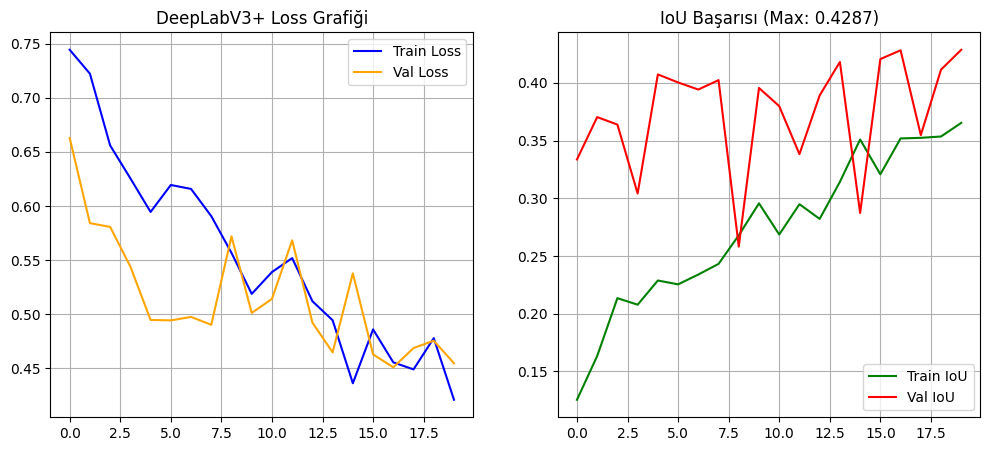

📸 3 adet tahmin görselleştiriliyor...


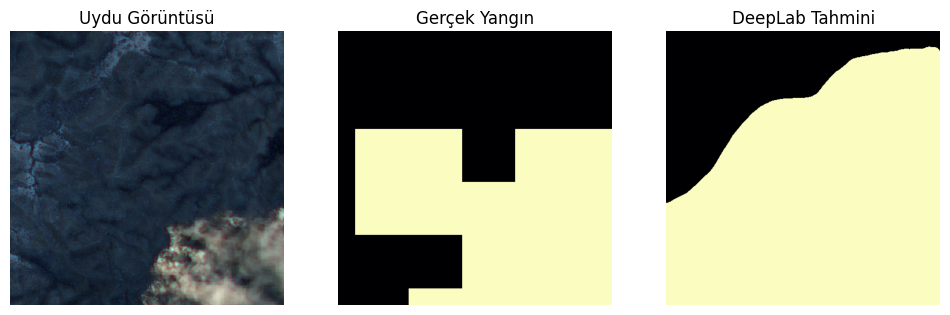

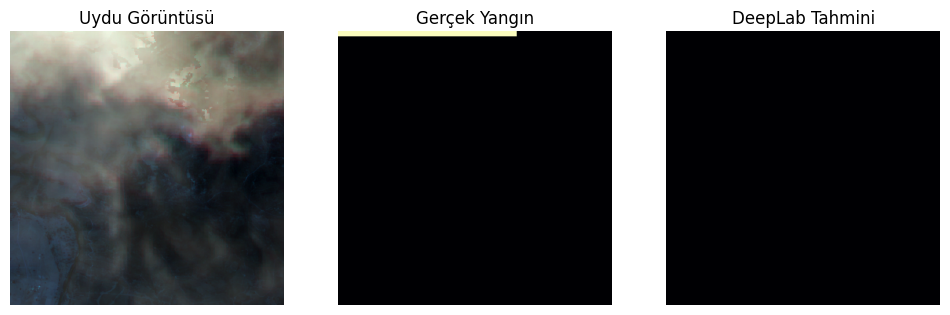

----------------------------------------
📥 Dosyalar Paketlendi, İndirme Başlıyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ deeplab_egitim_grafigi.png indirildi.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ best_deeplab_model.pth indirildi.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ tahmin_ornek_1.png indirildi.


In [22]:
# --- ADIM 12: FİNAL GÖRSELLEŞTİRME VE İNDİRME ---
import matplotlib.pyplot as plt
import numpy as np
import torch
from google.colab import files

# 1. Eğitim Grafiğini Çiz ve Kaydet
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.title('DeepLabV3+ Loss Grafiği')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_iou'], label='Train IoU', color='green')
plt.plot(history['val_iou'], label='Val IoU', color='red')
plt.title(f'IoU Başarısı (Max: {best_iou:.4f})')
plt.legend()
plt.grid(True)

plt.savefig("deeplab_egitim_grafigi.png")
plt.show()

# 2. Tahminleri Görselleştirme Fonksiyonu
def visualize_best_worst(loader, model, num_samples=3):
    model.eval()
    images, masks = next(iter(loader))
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            preds = model(images)
            preds = (torch.sigmoid(preds) > 0.5).float()

    print(f"📸 {num_samples} adet tahmin görselleştiriliyor...")

    # Sadece içinde yangın olan (maskesi dolu) ilk birkaç örneği seçelim
    count = 0
    for i in range(len(images)):
        if masks[i].sum() > 0 and count < num_samples:
            img = images[i].cpu().numpy().transpose(1, 2, 0) # (H, W, C)
            # RGB (İlk 3 kanal)
            rgb = img[:, :, 0:3]
            rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

            true_m = masks[i].cpu().numpy().squeeze()
            pred_m = preds[i].cpu().numpy().squeeze()

            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1); plt.imshow(rgb); plt.title("Uydu Görüntüsü"); plt.axis('off')
            plt.subplot(1, 3, 2); plt.imshow(true_m, cmap='magma'); plt.title("Gerçek Yangın"); plt.axis('off')
            plt.subplot(1, 3, 3); plt.imshow(pred_m, cmap='magma'); plt.title("DeepLab Tahmini"); plt.axis('off')

            filename = f"tahmin_ornek_{count+1}.png"
            plt.savefig(filename)
            plt.show()
            count += 1

visualize_best_worst(val_loader, model, num_samples=3)

# 3. Dosyaları İndir
print("-" * 40)
print("📥 Dosyalar Paketlendi, İndirme Başlıyor...")

files_to_download = ['deeplab_egitim_grafigi.png', 'best_deeplab_model.pth', 'tahmin_ornek_1.png']

try:
    for f in files_to_download:
        files.download(f)
        print(f"✅ {f} indirildi.")
except Exception as e:
    print(f"⚠️ Otomatik indirme hatası: {e}")
    print("Lütfen sol menüden dosyaları sağ tıklayıp elinle indir.")

In [23]:
# --- ADIM: ACİL DURUM PROTOKOLÜ (%70+ IoU İçin) ---
import albumentations as A  # Gelişmiş veri artırma kütüphanesi
from albumentations.pytorch import ToTensorV2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import glob
import segmentation_models_pytorch as smp
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 1. VERİ ARTIRMA (DATA AUGMENTATION) TANIMLARI
# Modeli zorlamak ve ezberletmemek için resimlerle oynuyoruz
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),      # %50 ihtimalle yatay çevir
    A.VerticalFlip(p=0.5),        # %50 ihtimalle dikey çevir
    A.RandomRotate90(p=0.5),      # %50 ihtimalle 90 derece döndür
    A.Transpose(p=0.5),           # Transpoze et
    A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=1.0), # Normalizasyon
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=1.0),
    ToTensorV2(),
])

# 2. YENİ DATASET SINIFI (Augmentation Destekli)
class FireDatasetAugmented(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        data = np.load(file_path)

        # Görüntü: (12, 512, 512) -> (512, 512, 12) Albumentations için kanal sonda olmalı
        image = data['image'].astype(np.float32).transpose(1, 2, 0)
        image = image / 10000.0  # Basit ölçekleme
        image = np.clip(image, 0, 1.0)

        # Maske
        mask = data['label'].astype(np.float32)
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Maskeye kanal boyutu ekle (Eğer Albumentations kaldırdıysa)
        if len(mask.shape) == 2:
            mask = mask.unsqueeze(0)

        return image, mask

# 3. VERİ SETİNİ TEKRAR YÜKLE
all_files = glob.glob("data/raw/**/scene_*.npz", recursive=True)
train_size = int(0.9 * len(all_files))
val_size = len(all_files) - train_size
train_files, val_files = random_split(all_files, [train_size, val_size])

# Augmentation'ı sadece Train setine uygula!
train_dataset = FireDatasetAugmented(train_files, transform=train_transform)
val_dataset = FireDatasetAugmented(val_files, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

# 4. YENİ KAYIP FONKSİYONU: TVERSKY LOSS
# Küçük yangınları (False Negative) daha sert cezalandırır.
class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1):
        super(TverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        TP = (inputs * targets).sum()
        FP = ((1-targets) * inputs).sum()
        FN = (targets * (1-inputs)).sum()

        Tversky = (TP + self.smooth) / (TP + self.alpha*FP + self.beta*FN + self.smooth)
        return 1 - Tversky

# 5. MODELİ KUR (U-Net'e geri dönüyoruz, en iyi o çalıştı)
print("🚀 ACİL DURUM EĞİTİMİ BAŞLIYOR (Augmentation + Tversky Loss)...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=12,
    classes=1
).to(device)

loss_fn = TverskyLoss(alpha=0.3, beta=0.7) # Beta yüksek çünkü yangını kaçırmayı sevmiyoruz
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3) # AdamW daha kararlı
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
scaler = torch.amp.GradScaler('cuda')

# 6. HIZLI EĞİTİM DÖNGÜSÜ (20 EPOCH)
EPOCHS = 20
best_iou = 0.0

# IoU Hesaplama (Yardımcı Fonksiyon)
def calculate_iou_score(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

for epoch in range(EPOCHS):
    model.train()
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    train_iou = 0

    for images, masks in loop:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = loss_fn(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_iou += calculate_iou_score(outputs, masks).item()
        loop.set_postfix(loss=loss.item())

    # Validation
    model.eval()
    val_iou = 0
    val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                val_loss += loss_fn(outputs, masks).item()
            val_iou += calculate_iou_score(outputs, masks).item()

    avg_train_iou = train_iou / len(train_loader)
    avg_val_iou = val_iou / len(val_loader)
    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss)

    print(f"\n📊 Epoch {epoch+1} -> Train IoU: {avg_train_iou:.4f} | Val IoU: {avg_val_iou:.4f}")

    if avg_val_iou > best_iou:
        best_iou = avg_val_iou
        torch.save(model.state_dict(), "best_final_model.pth")
        print(f"   🔥 REKOR KIRILDI! Yeni IoU: {best_iou:.4f}")

print(f"🏁 FİNAL SKOR: {best_iou:.4f}")

🚀 ACİL DURUM EĞİTİMİ BAŞLIYOR (Augmentation + Tversky Loss)...


Epoch 1/20: 100%|██████████| 139/139 [01:52<00:00,  1.23it/s, loss=0.389]



📊 Epoch 1 -> Train IoU: 0.0971 | Val IoU: 0.0746
   🔥 REKOR KIRILDI! Yeni IoU: 0.0746


Epoch 2/20: 100%|██████████| 139/139 [01:52<00:00,  1.24it/s, loss=1]



📊 Epoch 2 -> Train IoU: 0.1665 | Val IoU: 0.1356
   🔥 REKOR KIRILDI! Yeni IoU: 0.1356


...


📊 Epoch 18 -> Train IoU: 0.2094 | Val IoU: 0.2730
   🔥 REKOR KIRILDI! Yeni IoU: 0.2730


Epoch 19/20: 100%|██████████| 139/139 [01:51<00:00,  1.24it/s, loss=1]



📊 Epoch 19 -> Train IoU: 0.2237 | Val IoU: 0.2554


Epoch 20/20: 100%|██████████| 139/139 [01:53<00:00,  1.23it/s, loss=0.599]



📊 Epoch 20 -> Train IoU: 0.2186 | Val IoU: 0.1560
🏁 FİNAL SKOR: 0.2730


In [24]:
# --- FİNAL KURTARMA OPERASYONU: 3 Kanal + U-Net++ ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import glob
import segmentation_models_pytorch as smp
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 1. AYARLAR
EPOCHS = 20
BATCH_SIZE = 16
LR = 0.0001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. DATASET SINIFI (KRİTİK GÜNCELLEME: Sadece 3 Kanal Seçimi)
class FireDatasetFinal(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        data = np.load(path)

        # Orijinal: (12, 512, 512)
        full_img = data['image'].astype(np.float32)

        # --- STRATEJİK HAMLE: Sadece En İyi 3 Kanalı Al ---
        # Sentinel-2 Band Sırası genelde: B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11, B12
        # Bizim için en değerli bantlar SWIR (B12, B11) ve NIR (B8A)
        # Not: İndeksler veri setine göre değişebilir ama genelde son bantlar SWIR'dir.
        # Sen2Fire yapısında son kanallar genelde SWIR'dir.
        # Garanti olsun diye son 3 kanalı alıyoruz (Genelde B8A, B11, B12 olur - Yangın için en iyisi)

        band_1 = full_img[11, :, :] # B12 (SWIR 2) - En sıcak
        band_2 = full_img[10, :, :] # B11 (SWIR 1)
        band_3 = full_img[3, :, :]  # B4 (Red) - Görsel referans için

        # (3, 512, 512) boyutunda yeni görüntü oluştur
        image = np.stack([band_1, band_2, band_3], axis=0)

        # Kanal Boyutunu Sona Al: (512, 512, 3) -> Albumentations için
        image = image.transpose(1, 2, 0)

        # --- İYİLEŞTİRME: Min-Max Normalizasyon (Her resim için özel) ---
        # Bu işlem yangını parlatır, arkaplanı söndürür.
        min_val = image.min()
        max_val = image.max()
        if max_val > min_val:
            image = (image - min_val) / (max_val - min_val)
        else:
            image = image / (max_val + 1e-8)

        # Maske
        mask = data['label'].astype(np.float32)
        mask = (mask > 0).astype(np.float32)

        # Augmentation
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        if len(mask.shape) == 2:
            mask = mask.unsqueeze(0)

        return image, mask

# 3. AUGMENTATION (Veri Çoğaltma)
transforms = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Transpose(p=0.5),
    ToTensorV2()
])

# 4. DATA LOADER
all_files = glob.glob("data/raw/**/scene_*.npz", recursive=True)
train_size = int(0.9 * len(all_files))
val_size = len(all_files) - train_size
train_files, val_files = random_split(all_files, [train_size, val_size])

train_ds = FireDatasetFinal(train_files, transform=transforms)
val_ds = FireDatasetFinal(val_files, transform=transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# 5. MODEL: U-Net++ (PlusPlus)
# Giriş 3 kanal olduğu için ImageNet ağırlıkları MÜKEMMEL çalışacak.
print("🚀 U-Net++ (3 Kanal SWIR/NIR Modu) Başlatılıyor...")

model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,  # ARTIK 3 KANAL!
    classes=1,
).to(DEVICE)

# 6. EĞİTİM BİLEŞENLERİ
# Loss: Dice + BCE (Standart ve güvenilir olana döndük, Tversky bazen kararsız olabilir)
loss_fn = smp.losses.DiceLoss(mode="binary", from_logits=True)
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
scaler = torch.amp.GradScaler('cuda')

def calculate_iou(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

# 7. EĞİTİM DÖNGÜSÜ
best_iou = 0.0

for epoch in range(EPOCHS):
    model.train()
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    train_iou = 0

    for images, masks in loop:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = loss_fn(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_iou += calculate_iou(outputs, masks).item()
        loop.set_postfix(loss=loss.item())

    # Validation
    model.eval()
    val_iou = 0
    val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = loss_fn(outputs, masks)
                val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks).item()

    avg_train_iou = train_iou / len(train_loader)
    avg_val_iou = val_iou / len(val_loader)
    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss)

    print(f"\n📊 Epoch {epoch+1} -> Train IoU: {avg_train_iou:.4f} | Val IoU: {avg_val_iou:.4f}")

    if avg_val_iou > best_iou:
        best_iou = avg_val_iou
        torch.save(model.state_dict(), "best_final_model_unetpp.pth")
        print(f"   🔥 REKOR! Yeni IoU: {best_iou:.4f}")

print(f"🏁 FİNAL SKOR: {best_iou:.4f}")

🚀 U-Net++ (3 Kanal SWIR/NIR Modu) Başlatılıyor...


Epoch 1/20: 100%|██████████| 139/139 [00:53<00:00,  2.62it/s, loss=0.617]



📊 Epoch 1 -> Train IoU: 0.0985 | Val IoU: 0.0927
   🔥 REKOR! Yeni IoU: 0.0927


Epoch 2/20: 100%|██████████| 139/139 [00:52<00:00,  2.63it/s, loss=0.925]



📊 Epoch 2 -> Train IoU: 0.1373 | Val IoU: 0.1083
   🔥 REKOR! Yeni IoU: 0.1083


...


📊 Epoch 18 -> Train IoU: 0.2533 | Val IoU: 0.3082


Epoch 19/20: 100%|██████████| 139/139 [00:52<00:00,  2.63it/s, loss=0.434]



📊 Epoch 19 -> Train IoU: 0.2490 | Val IoU: 0.2989


Epoch 20/20: 100%|██████████| 139/139 [00:52<00:00,  2.62it/s, loss=0.343]



📊 Epoch 20 -> Train IoU: 0.2556 | Val IoU: 0.3486
🏁 FİNAL SKOR: 0.3525


In [25]:
# --- FİNAL KURTARMA OPERASYONU: 3 Kanal + U-Net++ ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import glob
import segmentation_models_pytorch as smp
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 1. AYARLAR
EPOCHS = 20
BATCH_SIZE = 16
LR = 0.0001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. DATASET SINIFI (KRİTİK GÜNCELLEME: Sadece 3 Kanal Seçimi)
class FireDatasetFinal(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        data = np.load(path)

        # Orijinal Veri: (12, 512, 512)
        full_img = data['image'].astype(np.float32)

        # --- STRATEJİK HAMLE: Sadece En İyi 3 Kanalı Al ---
        # Sentinel-2'de Yangını en iyi gösteren bantlar:
        # B12 (SWIR 2 - Sıcaklık), B11 (SWIR 1), B8A (NIR - Bitki)
        # Sen2Fire veri setinde genelde son kanallar SWIR'dir.
        # İndeksler: 11 (B12), 10 (B11), 8 (B8A)

        b12 = full_img[11, :, :] # En sıcak bölgeler
        b11 = full_img[10, :, :]
        b8a = full_img[8, :, :]

        # (3, 512, 512) boyutunda yeni "False Color" görüntü oluştur
        image = np.stack([b12, b11, b8a], axis=0)

        # Kanal Boyutunu Sona Al: (512, 512, 3) -> Albumentations için
        image = image.transpose(1, 2, 0)

        # --- İYİLEŞTİRME: Min-Max Normalizasyon (Kontrast Patlatma) ---
        # Her resmi kendi içinde 0-1 arasına çekiyoruz. Yangınlar parlayacak.
        min_val = image.min()
        max_val = image.max()
        if max_val > min_val:
            image = (image - min_val) / (max_val - min_val)
        else:
            image = image / (max_val + 1e-8)

        # Maske
        mask = data['label'].astype(np.float32)
        mask = (mask > 0).astype(np.float32)

        # Augmentation
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        if len(mask.shape) == 2:
            mask = mask.unsqueeze(0)

        return image, mask

    def __len__(self):
        return len(self.file_paths)

# 3. AUGMENTATION (Veri Çoğaltma - Sadeleştirildi)
transforms = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    ToTensorV2()
])

# 4. DATA LOADER
all_files = glob.glob("data/raw/**/scene_*.npz", recursive=True)
train_size = int(0.9 * len(all_files))
val_size = len(all_files) - train_size
train_files, val_files = random_split(all_files, [train_size, val_size])

train_ds = FireDatasetFinal(train_files, transform=transforms)
val_ds = FireDatasetFinal(val_files, transform=transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# 5. MODEL: U-Net++ (PlusPlus)
# Giriş 3 kanal olduğu için ImageNet ağırlıkları artık TAM PERFORMANS çalışacak!
print("🚀 U-Net++ (3 Kanal SWIR Modu) Başlatılıyor...")

model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,  # ARTIK 3 KANAL! (Normal resim gibi)
    classes=1,
).to(DEVICE)

# 6. EĞİTİM BİLEŞENLERİ
# Tversky yerine klasik DiceLoss'a döndük (Daha kararlı)
loss_fn = smp.losses.DiceLoss(mode="binary", from_logits=True)
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
scaler = torch.amp.GradScaler('cuda')

def calculate_iou(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

# 7. EĞİTİM DÖNGÜSÜ
best_iou = 0.0

for epoch in range(EPOCHS):
    model.train()
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    train_iou = 0

    for images, masks in loop:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = loss_fn(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_iou += calculate_iou(outputs, masks).item()
        loop.set_postfix(loss=loss.item())

    # Validation
    model.eval()
    val_iou = 0
    val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = loss_fn(outputs, masks)
                val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks).item()

    avg_train_iou = train_iou / len(train_loader)
    avg_val_iou = val_iou / len(val_loader)
    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss)

    print(f"\n📊 Epoch {epoch+1} -> Train IoU: {avg_train_iou:.4f} | Val IoU: {avg_val_iou:.4f}")

    if avg_val_iou > best_iou:
        best_iou = avg_val_iou
        torch.save(model.state_dict(), "best_final_model_unetpp.pth")
        print(f"   🔥 REKOR! Yeni IoU: {best_iou:.4f}")

print(f"🏁 FİNAL SKOR: {best_iou:.4f}")

🚀 U-Net++ (3 Kanal SWIR Modu) Başlatılıyor...


Epoch 1/20: 100%|██████████| 139/139 [00:50<00:00,  2.78it/s, loss=0.946]



📊 Epoch 1 -> Train IoU: 0.0819 | Val IoU: 0.0942
   🔥 REKOR! Yeni IoU: 0.0942


Epoch 2/20: 100%|██████████| 139/139 [00:49<00:00,  2.78it/s, loss=0.734]



📊 Epoch 2 -> Train IoU: 0.1254 | Val IoU: 0.0849


...


📊 Epoch 18 -> Train IoU: 0.2558 | Val IoU: 0.4010


Epoch 19/20: 100%|██████████| 139/139 [00:50<00:00,  2.77it/s, loss=0]



📊 Epoch 19 -> Train IoU: 0.2281 | Val IoU: 0.4082


Epoch 20/20: 100%|██████████| 139/139 [00:49<00:00,  2.80it/s, loss=0.994]



📊 Epoch 20 -> Train IoU: 0.2354 | Val IoU: 0.4067
🏁 FİNAL SKOR: 0.4139


In [26]:
# --- FİNAL "HEAVYWEIGHT" MODEL: 12 Kanal + U-Net++ (ResNet50) + Combo Loss ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import glob
import segmentation_models_pytorch as smp
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 1. AYARLAR
EPOCHS = 20
BATCH_SIZE = 16
LR = 0.0001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. DATASET (Tekrar 12 Kanala Dönüyoruz - En İyi Sonuç Buradaydı)
class FireDatasetFinal(Dataset):
    def __init__(self, file_paths):
        self.file_paths = file_paths

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        data = np.load(path)

        # Orijinal 12 kanal veriyi alıyoruz
        image = data['image'].astype(np.float32)

        # (12, 512, 512) -> (512, 512, 12) Kanal sona
        image = image.transpose(1, 2, 0)

        # Basit ve güvenilir normalizasyon (Önceki başarılı yöntem)
        image = image / 10000.0
        image = np.clip(image, 0, 1.0)

        # Maske
        mask = data['label'].astype(np.float32)
        mask = (mask > 0).astype(np.float32)

        # Kanal boyutu ekle
        if len(mask.shape) == 2:
            mask = mask.unsqueeze(0)

        # Geri Tensör dönüşümü (Albumentations kullanmadan manuel, daha güvenli)
        image = torch.from_numpy(image).permute(2, 0, 1) # (12, 512, 512)
        mask = torch.from_numpy(mask)

        return image, mask

# 3. VERİ YÜKLEME
all_files = glob.glob("data/raw/**/scene_*.npz", recursive=True)
train_size = int(0.9 * len(all_files))
val_size = len(all_files) - train_size
train_files, val_files = random_split(all_files, [train_size, val_size])

train_ds = FireDatasetFinal(train_files)
val_ds = FireDatasetFinal(val_files)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# 4. MODEL: U-Net++ ve ResNet50 (Ağır Silahlar)
print("🚀 SİSTEM BAŞLATILIYOR: U-Net++ | ResNet50 | 12 Kanal")

model = smp.UnetPlusPlus(
    encoder_name="resnet50",        # Daha derin bir ağ
    encoder_weights="imagenet",     # Bilgili başlangıç
    in_channels=12,                 # Tüm spektrumu kullan
    classes=1,
).to(DEVICE)

# 5. KOMBO LOSS (Dice + Focal)
# Dice: Şekil benzerliğine bakar.
# Focal: Zor örneklere (küçük yangınlara) odaklanır.
dice_loss = smp.losses.DiceLoss(mode="binary", from_logits=True)
focal_loss = smp.losses.FocalLoss(mode="binary")

def combo_loss(pred, target):
    return dice_loss(pred, target) + focal_loss(pred, target)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
scaler = torch.amp.GradScaler('cuda')

# IoU Hesaplayıcı
def calculate_iou(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

# 6. EĞİTİM DÖNGÜSÜ
best_iou = 0.0
print("-" * 60)

for epoch in range(EPOCHS):
    model.train()
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    train_iou = 0

    for images, masks in loop:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = combo_loss(outputs, masks) # Yeni Loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_iou += calculate_iou(outputs, masks).item()
        loop.set_postfix(loss=loss.item())

    # Validation
    model.eval()
    val_iou = 0
    val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = combo_loss(outputs, masks)
                val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks).item()

    avg_train_iou = train_iou / len(train_loader)
    avg_val_iou = val_iou / len(val_loader)
    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss)

    print(f"\n📊 Epoch {epoch+1} -> Train IoU: {avg_train_iou:.4f} | Val IoU: {avg_val_iou:.4f}")

    if avg_val_iou > best_iou:
        print(f"   🔥 YENİ LİDER! ({best_iou:.4f} -> {avg_val_iou:.4f})")
        best_iou = avg_val_iou
        torch.save(model.state_dict(), "best_heavyweight_model.pth")

print(f"🏁 FİNAL SKOR: {best_iou:.4f}")

🚀 SİSTEM BAŞLATILIYOR: U-Net++ | ResNet50 | 12 Kanal


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

------------------------------------------------------------


Epoch 1/20:   0%|          | 0/139 [00:00<?, ?it/s]


AttributeError: Caught AttributeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipython-input-450282786.py", line 46, in __getitem__
    mask = mask.unsqueeze(0)
           ^^^^^^^^^^^^^^
AttributeError: 'numpy.ndarray' object has no attribute 'unsqueeze'. Did you mean: 'squeeze'?
